# pyNamo Tutorial

This notebook introduces the main pyNamo workflow: define or load a game, plot its replicator dynamics, inspect equilibria, and save publication-quality figures.

## 1. Setup

For ordinary use, the imports below are enough. If you are editing the package source while this notebook is open, use `importlib.reload(...)` in your development notebook.

In [32]:
import numpy as np
import matplotlib.pyplot as plt

import importlib

import game
import dynamics
import analysis
import examples
import drawer
import interactive

game = importlib.reload(game)
dynamics = importlib.reload(dynamics)
analysis = importlib.reload(analysis)
examples = importlib.reload(examples)
drawer = importlib.reload(drawer)
interactive = importlib.reload(interactive)


%matplotlib widget

## Mathematical Model

pyNamo studies deterministic replicator dynamics for finite normal-form games. A state is a vector of mixed strategies or population frequencies.

For a symmetric one-population game with payoff matrix $A$ and population state $x \in \Delta^{m-1}$, the expected payoff of pure strategy $i$ is

$$
(Ax)_i,
$$

and the average population payoff is

$$
x^T A x.
$$

The replicator dynamic is

$$
\dot{x}_i = x_i\left((Ax)_i - x^T A x\right).
$$

The simplex is forward invariant: if $x_i \geq 0$ for all $i$ and $\sum_i x_i = 1$, then trajectories remain in the simplex.

## Asymmetric Replicator Dynamics

For an asymmetric $n$-player game, each player or population $p$ has a mixed strategy

$$
x^p \in \Delta^{m-1}.
$$

Given the mixed strategies of the other players, the expected payoff of pure strategy $i$ for player $p$ is written

$$
u_i^p(x^{-p}).
$$

The average payoff to player $p$ is

$$
\bar{u}^p(x) = \sum_i x_i^p u_i^p(x^{-p}).
$$

The replicator equation for player $p$ is

$$
\dot{x}_i^p = x_i^p\left(u_i^p(x^{-p}) - \bar{u}^p(x)\right).
$$

For 2-strategy asymmetric games, pyNamo represents each player's mixed strategy by one coordinate: the probability of the first listed strategy.

## Reduced Coordinates

The package works in reduced coordinates whenever the simplex constraint makes one coordinate redundant.

For a 3-strategy symmetric game,

$$
x = (x_1, x_2, 1 - x_1 - x_2).
$$

For a 4-strategy symmetric game,

$$
x = (x_1, x_2, x_3, 1 - x_1 - x_2 - x_3).
$$

For asymmetric 2-strategy games, no residual coordinate is displayed in the table because each population contributes one independent coordinate.

## 2. First Plot In One Line

`drawer.phase_portrait` is the recommended plotting interface. It accepts a `Game` object and automatically chooses the correct state space.

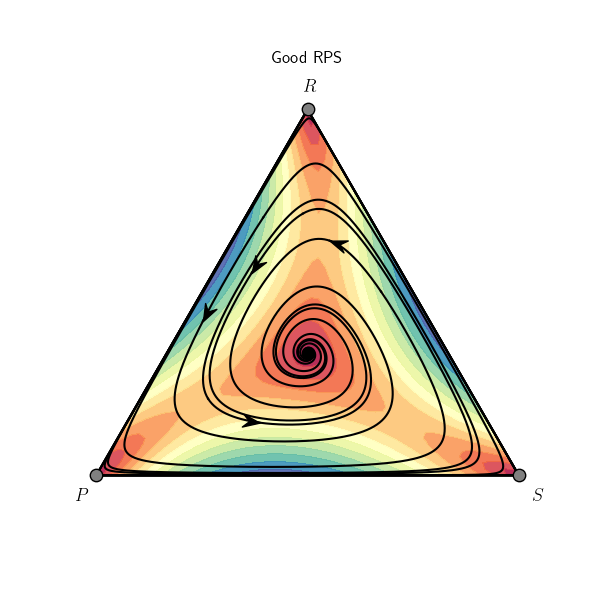

In [4]:
fig, ax = drawer.phase_portrait(examples.games.good_rps)
plt.show()

## 3. Built-In Examples

The built-in catalogue is available as `examples.games`. Games can be accessed by attribute, by name, or by game class.

In [5]:
examples.games.names()

['good_rps',
 'hawk_dove_retaliator',
 'standard_rps',
 'coordination_123',
 'pure_coordination',
 'repeated_pd_tft_allc_alld',
 'matching_pennies',
 'two_player_hawk_dove',
 'battle_of_the_sexes',
 'predator_prey_behavioral_conflict',
 'hofbauer_swinkels',
 'skyrms_1992',
 'ownership_game',
 'coordination_cube',
 'cyclic_mismatching_pennies',
 'cyclic_matching_pennies']

In [6]:
my_game = examples.games.battle_of_the_sexes

{
    "Name": my_game.name,
    "Game class": my_game.game_class,
    "Symmetric": my_game.symmetric,
    "Player labels": my_game.player_labels,
    "Strategy labels by player": my_game.player_strategy_labels,
    "Payoff matrices": my_game.payoff_data,
}

{'Name': 'Battle of the Sexes',
 'Game class': '2P2S',
 'Symmetric': False,
 'Player labels': ['Population 1', 'Population 2'],
 'Strategy labels by player': [['B', 'S'], ['B', 'S']],
 'Payoff matrices': (array([[2., 0.],
         [0., 1.]]),
  array([[1., 0.],
         [0., 2.]]))}

## 4. Defining Your Own Game

Symmetric games are defined with one payoff matrix. Entry `(i, j)` is the payoff to a player using strategy `i` against an opponent using strategy `j`.

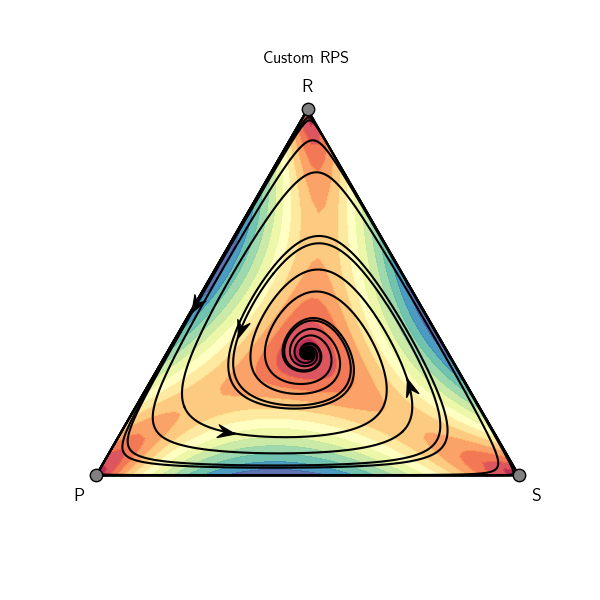

In [7]:
custom_rock_paper_scissors = game.Game(
    "Custom RPS",
    np.array([
        [0, -1, 2],
        [2, 0, -1],
        [-1, 2, 0],
    ], dtype=float),
    strategy_labels=["R", "P", "S"],
)

fig, ax = drawer.phase_portrait(custom_rock_paper_scissors)
plt.show()

## 5. Coordinate Conventions

For symmetric 2-player / 3-strategy games, a state `[x1, x2]` gives the first two strategy frequencies; the third is `1 - x1 - x2`.

For symmetric 2-player / 4-strategy games, a state `[x1, x2, x3]` gives the first three strategy frequencies; the fourth is `1 - x1 - x2 - x3`.

For asymmetric 2-player / 2-strategy games, a state `[x, y]` gives the probability that player 1 and player 2 use their first listed strategy.

For asymmetric 3-player / 2-strategy games, a state `[x, y, z]` gives the probability that players 1, 2, and 3 use their first listed strategy.

## 6. Customizing Trajectories

Use `starts` to set initial conditions, `tmax` to set the integration horizon, and `trajectory_arrows=[]` to hide direction markers.

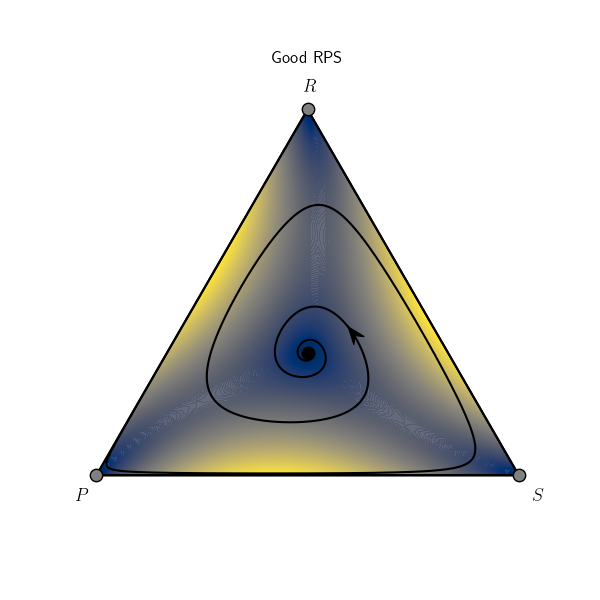

In [8]:
fig, ax = drawer.phase_portrait(
    examples.games.good_rps,
    starts=[[0.4, 0.2]],
    tmax=50,
    trajectory_arrows=[0.001],
    trajectory_color="black",
    speed_cmap=plt.cm.cividis,
    speed_levels=300
)
plt.show()

A single color applies to all trajectories. A list assigns one color per trajectory.

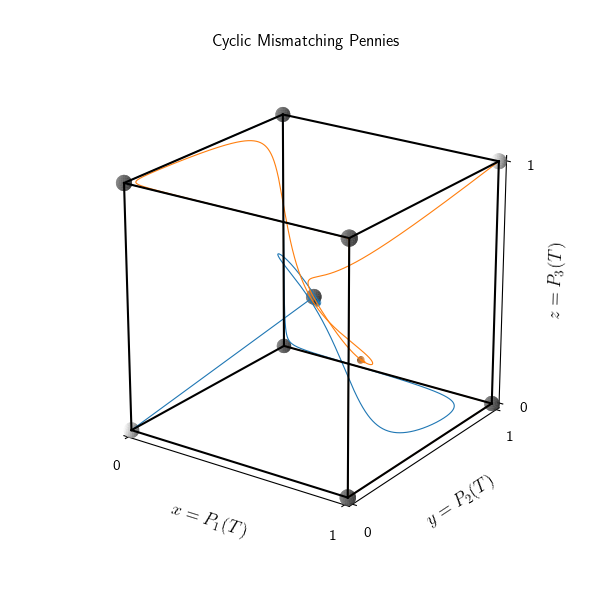

In [9]:
fig, ax = drawer.phase_portrait(
    game=examples.games.cyclic_mismatching_pennies,
    starts=[[0.52, 0.50, 0.48], [0.70, 0.45, 0.35]],
    trajectory_color=["tab:blue", "tab:orange"],
    trajectory_arrows=[0.001],
    tmax=1000,
    view_elev=22,
    view_azim=-55,
)
plt.show()

## 7. Speed Fields And Vector Fields

The vector field is the map

$$
F(x) = \dot{x}.
$$

A speed field shows the magnitude of motion at each point:

$$
\text{speed}(x) = \|F(x)\|.
$$

A vector field shows the local direction and magnitude of motion:

$$
x \mapsto F(x).
$$

Trajectories show realized paths from chosen initial conditions, i.e. solutions of

$$
\dot{x}(t) = F(x(t)).
$$

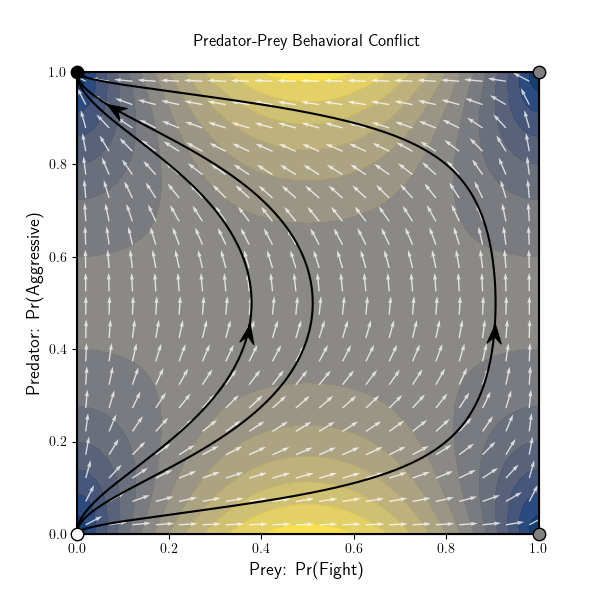

In [10]:
fig, ax = drawer.phase_portrait(
    examples.games.predator_prey_behavioral_conflict,
    show_vector_field=True,
    vector_color="white",
    vector_grid=20,
    speed_cmap=plt.cm.cividis,
    starts=[[0.2, 0.2], [0.8, 0.2], [0.3, 0.8]],
    tmax=60,
)
plt.show()

You can also plot only the vector field.

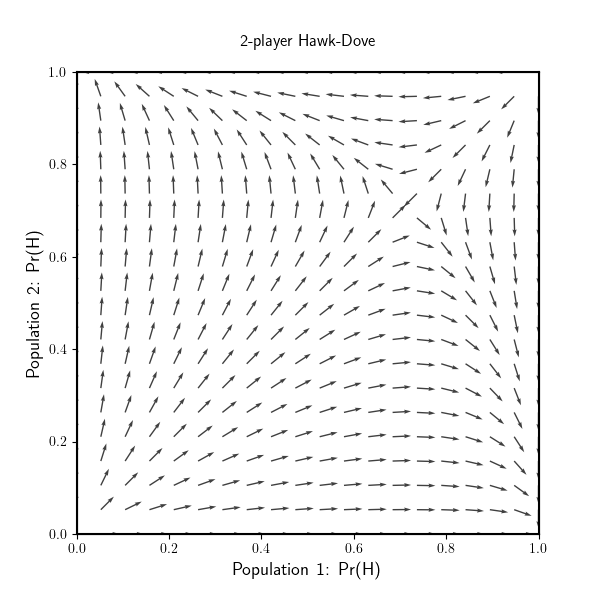

In [11]:
fig, ax = drawer.phase_portrait(
    examples.games.two_player_hawk_dove,
    show_speed=False,
    show_trajectories=False,
    show_equilibria=False,
    show_vector_field=True,
    vector_grid=20,
    vector_margin=0.0,
)
plt.show()

## Equilibria And Linear Stability

An equilibrium, or rest point, is a state $x^*$ such that

$$
F(x^*) = 0,
$$

where $F$ is the vector field induced by the replicator dynamics.

For isolated equilibria, pyNamo computes the Jacobian matrix of the reduced vector field,

$$
J(x^*) = DF(x^*),
$$

and analyzes the eigenvalues associated with admissible perturbations. The important point is that perturbations must stay within the state space. At a boundary point of the simplex, outward directions are not biologically or mathematically admissible deviations.

This is why pyNamo does not simply classify equilibria from all eigenvalues of an unconstrained ambient-space Jacobian.

## Stability Classification Used By pyNamo

For the admissible linearization, pyNamo uses the following conservative classification logic.

If all admissible eigenvalues have negative real part, the equilibrium is classified as a **sink**.

If all admissible eigenvalues have positive real part, the equilibrium is classified as a **source**.

If there are admissible eigenvalues with both positive and negative real parts, the equilibrium is classified as a **saddle**.

If the relevant eigenvalues have zero real part and nonzero imaginary part, the equilibrium is classified as a **center**.

If at least one admissible eigenvalue has positive real part but zero or unsupported directions prevent distinguishing source from saddle, the equilibrium is classified as **unstable**.

If the implemented criteria do not determine the case, the equilibrium is classified as **undetermined** and pyNamo emits a warning.

Numerical note: eigenvalues and eigenvectors are computed numerically. Very small imaginary parts may arise from floating-point error, especially near boundary equilibria or repeated eigenvalues. pyNamo treats tiny imaginary parts below tolerance as numerical noise when deciding which eigendirections are admissible.


## Degenerate Equilibrium Sets

Some games have continua of rest points rather than isolated equilibria: for example, an entire edge of the simplex may be stationary.

When the symbolic solver detects a parametric or non-isolated equilibrium set, pyNamo emits a warning. It does not automatically plot equilibrium manifolds. Isolated equilibria are still reported and plotted when they can be identified.

This is intentional. The package aims to provide a minimal, reliable automatic analysis rather than overclaiming in degenerate or non-hyperbolic cases.

/Users/slimane/Documents/GitHub/pyNamo/analysis.py:158: DegenerateEquilibriumWarning: Degenerate equilibrium solutions detected: SymPy returned a parametric/non-isolated solution set. Non-isolated equilibrium sets are not plotted; isolated equilibria are still shown when they can be identified.
  raw_equilibria = dynamics.compute_equilibria(payoff_data)
/Users/slimane/Documents/GitHub/pyNamo/drawer.py:661: InconclusiveStabilityWarning: Stability classification is inconclusive for equilibrium [0.0, 0.0, 1.0]: admissible linearization has eigenvalues with zero real part or unsupported eigendirections, and the implemented fallback did not establish asymptotic stability.
  result = analysis.analyze_equilibria(payoff_data)
/Users/slimane/Documents/GitHub/pyNamo/drawer.py:1092: PlottingWarning: At least one equilibrium is classified as 'unstable': linearization proves it is not stable, but does not distinguish source from saddle. For plotting compatibility, unstable equilibria are drawn with

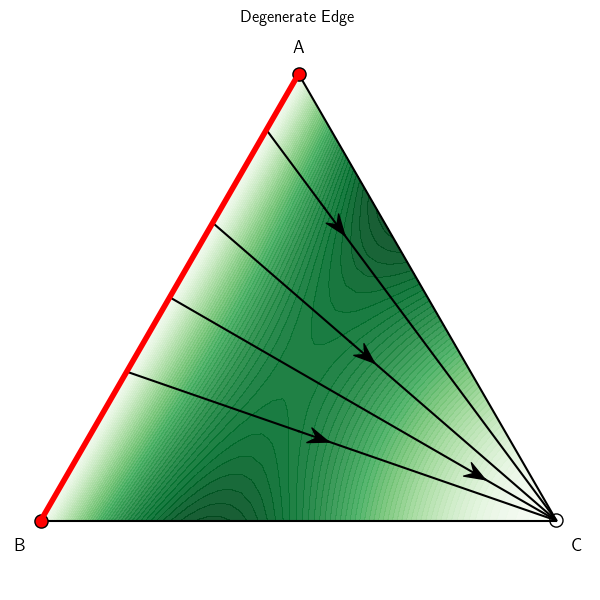

In [12]:
degenerate_edge_game = game.Game(
    "Degenerate Edge",
    np.array([
        [1, 1, 0],
        [1, 1, 0],
        [2, 2, 0],
    ], dtype=float),
    strategy_labels=["A", "B", "C"],
)

fig, ax = drawer.phase_portrait(
    degenerate_edge_game,
    starts=[
        [0.4, 0.2],
        [0.2, 0.4],
        [0.1, 0.1],
        [0.7, 0.1],
    ],
    tmax=500,
    trajectory_arrows=[0.001],
    trajectory_zorder=40,
    speed_cmap=plt.cm.Greens,
    speed_grid=50,
    speed_levels=50,
    sink_color="green",
    saddle_color="gold",
    source_color="red",
    equilibrium_size=90,
    equilibrium_zorder=45,
)

# The whole A-B edge is an equilibrium continuum. pyNamo warns about
# this degeneracy but does not automatically plot equilibrium manifolds.
ab_start = drawer.simplex_to_plane_2p3s(1, 0)  # pure A
ab_end = drawer.simplex_to_plane_2p3s(0, 1)    # pure B

ax.plot(
    [ab_start[0], ab_end[0]],
    [ab_start[1], ab_end[1]],
    color="red",
    linewidth=4,
    zorder=45,
    solid_capstyle="round",
)

plt.tight_layout()
plt.show()

The warning is also emitted when one produces the equilbrium analysis table (see below for more on that topic)

In [13]:
analysis.equilibrium_table(degenerate_edge_game)

/Users/slimane/Documents/GitHub/pyNamo/analysis.py:158: DegenerateEquilibriumWarning: Degenerate equilibrium solutions detected: SymPy returned a parametric/non-isolated solution set. Non-isolated equilibrium sets are not plotted; isolated equilibria are still shown when they can be identified.
  raw_equilibria = dynamics.compute_equilibria(payoff_data)
/Users/slimane/Documents/GitHub/pyNamo/analysis.py:242: InconclusiveStabilityWarning: Stability classification is inconclusive for equilibrium [0.0, 0.0, 1.0]: admissible linearization has eigenvalues with zero real part or unsupported eigendirections, and the implemented fallback did not establish asymptotic stability.
  return analyze_equilibria(game).to_dataframe(ndigits=ndigits)


,Position,Stability Status,Nash,ESS,Strict Nash,Eigenvalues,Eigenvectors,Warning
0,"[0.0, 0.0, 1.0]",undetermined,True,False,False,"[0.0, 0.0]","[[1.0, 0.0], [0.0, 1.0]]",Stability classification is inconclusive for e...
1,"[0.0, 1.0, 0.0]",unstable,False,False,False,"[1.0, 0.0]","[[0.0, 0.707107], [1.0, -0.707107]]",None
2,"[1.0, 0.0, 0.0]",unstable,False,False,False,"[1.0, 0.0]","[[1.0, -0.707107], [0.0, 0.707107]]",None


## 8. Equilibrium Analysis

`analysis.equilibrium_table` summarizes isolated equilibria. The `Position` column follows the same coordinate conventions described above.

In [14]:
analysis.equilibrium_table(examples.games.good_rps)

,Position,Stability Status,Nash,ESS,Strict Nash,Eigenvalues,Eigenvectors,Warning
0,"[0.0, 0.0, 1.0]",saddle,False,False,False,"[2.0, -1.0]","[[1.0, 0.0], [0.0, 1.0]]",None
1,"[0.0, 1.0, 0.0]",saddle,False,False,False,"[2.0, -1.0]","[[0.0, 0.707107], [1.0, -0.707107]]",None
2,"[0.333333, 0.333333, 0.333333]",sink,True,True,False,"[(-0.166667+0.866025j), (-0.166667-0.866025j)]","[[0.707107, 0.707107], [(-0.353553-0.612372j),...",None
3,"[1.0, 0.0, 0.0]",saddle,False,False,False,"[-1.0, 2.0]","[[1.0, -0.707107], [0.0, 0.707107]]",None


The table above finds static equilibria but this can also be done separately, e.g.:

In [15]:
analysis.find_nash(examples.games.battle_of_the_sexes)
# analysis.find_strict_nash(examples.games.battle_of_the_sexes)
# analysis.find_ess(examples.games.good_rps)

[array([0., 0.]), array([0.66666667, 0.33333333]), array([1., 1.])]

## 9. Asymmetric 2-Player Games

Asymmetric games can use player-specific strategy labels. Here the first coordinate is `Pr(Fight)` for prey, and the second is `Pr(Aggressive)` for predators.

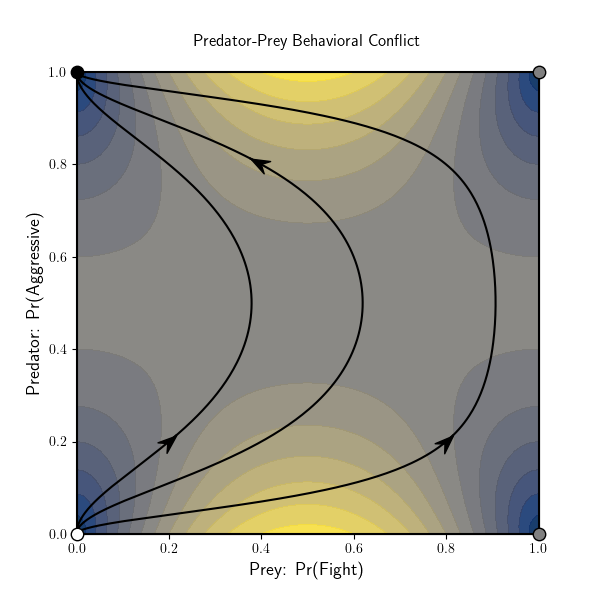

,Position,Stability Status,Nash,ESS,Strict Nash,Eigenvalues,Eigenvectors,Warning
0,"[0.0, 0.0]",source,False,None,False,"[2.0, 1.0]","[[1.0, 0.0], [0.0, 1.0]]",None
1,"[0.0, 1.0]",sink,True,None,True,"[-2.0, -1.0]","[[1.0, 0.0], [0.0, 1.0]]",None
2,"[1.0, 0.0]",saddle,False,None,False,"[-2.0, 1.0]","[[1.0, 0.0], [0.0, 1.0]]",None
3,"[1.0, 1.0]",saddle,False,None,False,"[2.0, -1.0]","[[1.0, 0.0], [0.0, 1.0]]",None


In [16]:
g = examples.games.predator_prey_behavioral_conflict

fig, ax = drawer.phase_portrait(
    g,
    starts=[[0.2, 0.2], [0.8, 0.2], [0.4, 0.8]],
    tmax=80,
    trajectory_arrows=[0.001],
    speed_cmap=plt.cm.cividis,
)
plt.show()

analysis.equilibrium_table(g)

## 10. 3D Simplex Example

Symmetric 4-strategy games are plotted on a tetrahedron. The plotted state `[x1, x2, x3]` omits the fourth coordinate, which is reconstructed as `1 - x1 - x2 - x3`.

/Users/slimane/Documents/GitHub/pyNamo/drawer.py:1092: PlottingWarning: At least one equilibrium is classified as 'unstable': linearization proves it is not stable, but does not distinguish source from saddle. For plotting compatibility, unstable equilibria are drawn with the source color and returned in the source bucket.
  plot_equilibria(


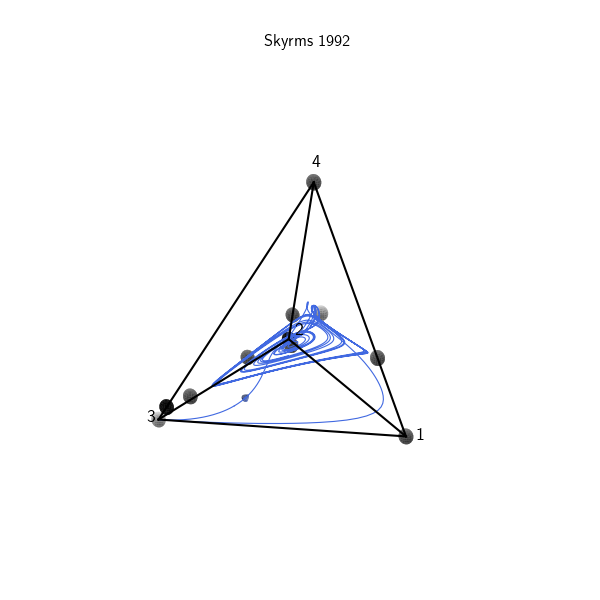

In [17]:
fig, ax = drawer.phase_portrait(
    examples.games.skyrms_1992,
    starts=[[0.22, 0.25, 0.25], [0.2, 0.2, 0.6]],
    trajectory_color="royalblue",
    trajectory_arrows=[0.001],
    tmax=80,
    view_elev=25,
    view_azim=35,
)
plt.show()

## 11. 3-Player Cube Example

Asymmetric 3-player / 2-strategy games are plotted on the cube. 3D vector fields are available, but trajectories are usually clearer in static figures.

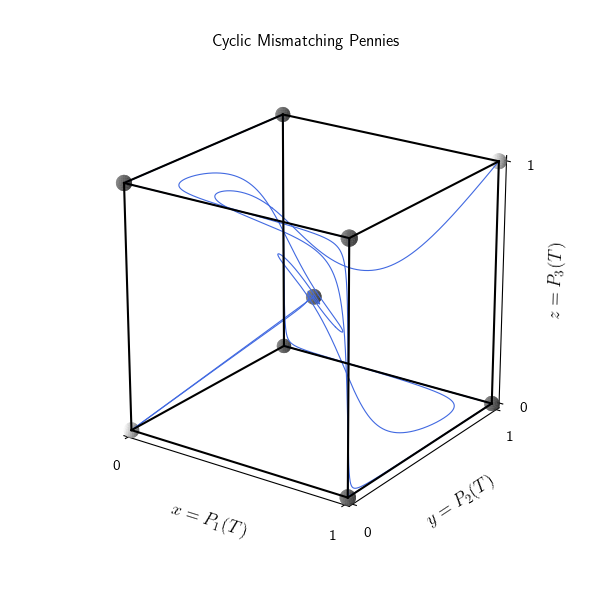

In [20]:
fig, ax = drawer.phase_portrait(
    examples.games.cyclic_mismatching_pennies,
    starts=[[0.52, 0.50, 0.48], [0.60, 0.50, 0.40], [0.20, 0.65, 0.75]],
    trajectory_color="royalblue",
    trajectory_arrows=[],
    tmax=1000,
    view_elev=22,
    view_azim=-55,
)
plt.show()

## 12. Saving Publication-Quality Figures

`phase_portrait` returns ordinary Matplotlib `fig, ax` objects. Save vector graphics with PDF or SVG, and raster graphics with high DPI.

In [ ]:
fig, ax = drawer.phase_portrait(
    examples.games.good_rps,
    starts=[[0.4, 0.2]],
    tmax=50,
    trajectory_arrows=[0.001],
    speed_cmap=plt.cm.cividis,
)

fig.savefig("good_rps_replicator_dynamics.pdf", bbox_inches="tight")
fig.savefig("good_rps_replicator_dynamics.svg", bbox_inches="tight")
fig.savefig("good_rps_replicator_dynamics.png", dpi=300, bbox_inches="tight")

plt.close(fig)


## 13. Interactive Widget

The interactive widget is useful for exploration and teaching. It requires `ipywidgets` and is intended for Jupyter notebooks.

In [36]:
plt.close(fig)

import importlib
import interactive

interactive = importlib.reload(interactive)
interactive.launch_replicator_widget()

NameError: name 'fig' is not defined

In [ ]:
%matplotlib widget

import importlib
import analysis
import interactive

analysis = importlib.reload(analysis)
interactive = importlib.reload(interactive)

interactive.launch_replicator_widget()